In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime

# Configuración de visualización
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")
%matplotlib inline

In [5]:
# 1. CARGA DE DATOS
df = pd.read_csv('abandono_clientes.csv')
df_nuevos = pd.read_csv('clientes_nuevos.csv')

In [6]:
# 2. INFORMACIÓN BÁSICA
print("\nINFORMACIÓN GENERAL DEL DATASET")
print("-"*60)
print(f"Dimensiones: {df.shape}")
print(f"\nPrimeras filas:")
print(df.head())
print(f"\nTipos de datos:")
print(df.dtypes)
print(f"\nInformación del DataFrame:")
df.info()


INFORMACIÓN GENERAL DEL DATASET
------------------------------------------------------------
Dimensiones: (900, 10)

Primeras filas:
              Names   Age  Total_Purchase  Account_Manager  Years  Num_Sites  \
0  Cameron Williams  42.0        11066.80                0   7.22        8.0   
1     Kevin Mueller  41.0        11916.22                0   6.50       11.0   
2       Eric Lozano  38.0        12884.75                0   6.67       12.0   
3     Phillip White  42.0         8010.76                0   6.71       10.0   
4    Cynthia Norton  37.0         9191.58                0   5.56        9.0   

          Onboard_date                                           Location  \
0  2013-08-30 07:00:40      10265 Elizabeth Mission Barkerburgh, AK 89518   
1  2013-08-13 00:38:46  6157 Frank Gardens Suite 019 Carloshaven, RI 1...   
2  2016-06-29 06:20:07             1331 Keith Court Alyssahaven, DE 90114   
3  2014-04-22 12:43:12       13120 Daniel Mount Angelabury, WY 30645-4695   



ANÁLISIS DE VALORES FALTANTES
------------------------------------------------------------
Empty DataFrame
Columns: [Columna, Valores Faltantes, Porcentaje (%)]
Index: []


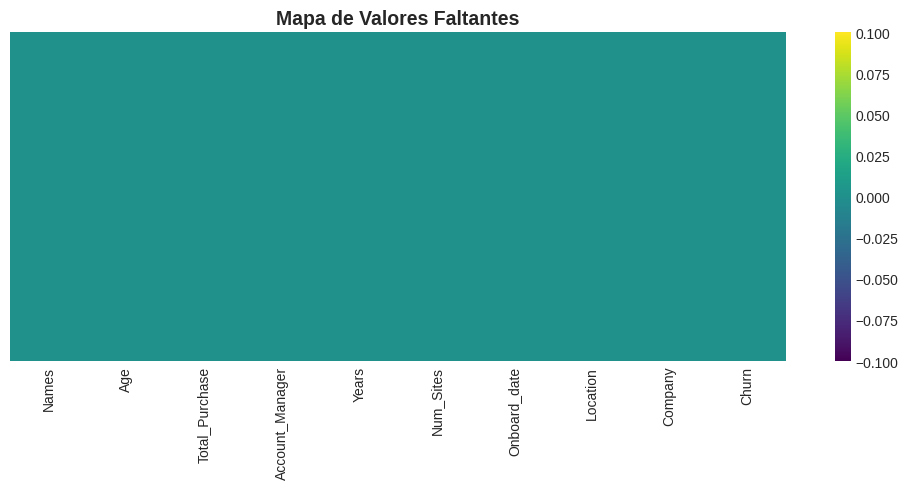

In [7]:
# 3. VALORES FALTANTES
print("\nANÁLISIS DE VALORES FALTANTES")
print("-"*60)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Columna': missing.index,
    'Valores Faltantes': missing.values,
    'Porcentaje (%)': missing_pct.values
})
print(missing_df[missing_df['Valores Faltantes'] > 0])

# Gráfica de valores faltantes
plt.figure(figsize=(10, 5))
sns.heatmap(df.isnull(), cbar=True, cmap='viridis', yticklabels=False)
plt.title('Mapa de Valores Faltantes', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

In [8]:
# 4. ESTADÍSTICAS DESCRIPTIVAS
print("\nESTADÍSTICAS DESCRIPTIVAS")
print("-"*60)
print(df.describe())


ESTADÍSTICAS DESCRIPTIVAS
------------------------------------------------------------
              Age  Total_Purchase  Account_Manager       Years   Num_Sites  \
count  900.000000      900.000000       900.000000  900.000000  900.000000   
mean    41.816667    10062.824033         0.481111    5.273156    8.587778   
std      6.127560     2408.644532         0.499921    1.274449    1.764836   
min     22.000000      100.000000         0.000000    1.000000    3.000000   
25%     38.000000     8497.122500         0.000000    4.450000    7.000000   
50%     42.000000    10045.870000         0.000000    5.215000    8.000000   
75%     46.000000    11760.105000         1.000000    6.110000   10.000000   
max     65.000000    18026.010000         1.000000    9.150000   14.000000   

            Churn  
count  900.000000  
mean     0.166667  
std      0.372885  
min      0.000000  
25%      0.000000  
50%      0.000000  
75%      0.000000  
max      1.000000  



DISTRIBUCIÓN DE CHURN
------------------------------------------------------------

Conteo:
Churn
0    750
1    150
Name: count, dtype: int64

Porcentaje:
Churn
0    83.333333
1    16.666667
Name: proportion, dtype: float64


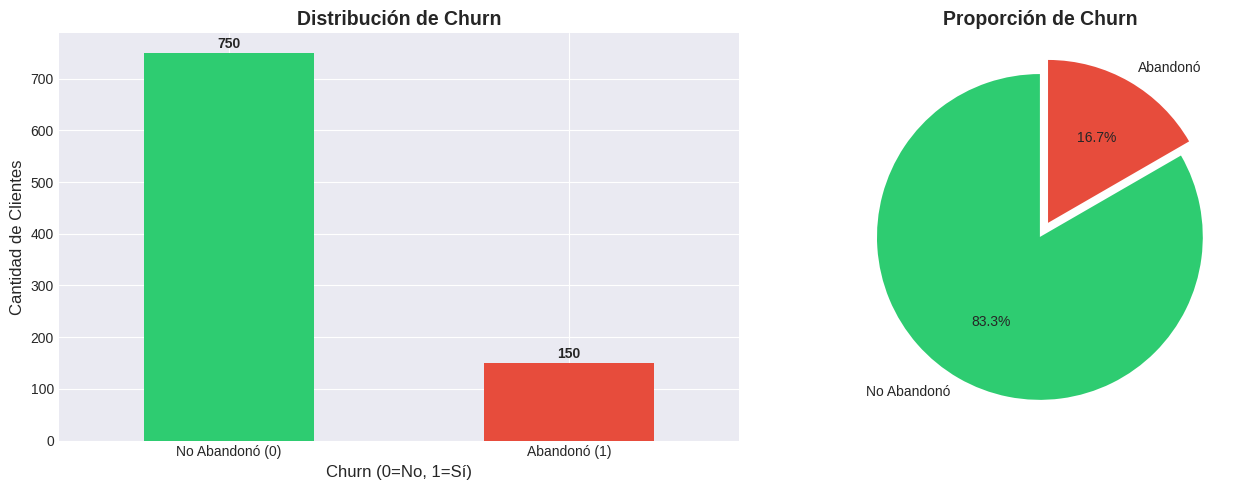

In [9]:
# 5. DISTRIBUCIÓN DE CHURN (VARIABLE OBJETIVO)
print("\nDISTRIBUCIÓN DE CHURN")
print("-"*60)
churn_counts = df['Churn'].value_counts()
churn_pct = df['Churn'].value_counts(normalize=True) * 100
print(f"\nConteo:\n{churn_counts}")
print(f"\nPorcentaje:\n{churn_pct}")

# Gráficas de Churn
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Gráfica de barras
churn_counts.plot(kind='bar', ax=axes[0], color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Distribución de Churn', fontsize=14, fontweight='bold')
axes[0].set_xlabel('Churn (0=No, 1=Sí)', fontsize=12)
axes[0].set_ylabel('Cantidad de Clientes', fontsize=12)
axes[0].set_xticklabels(['No Abandonó (0)', 'Abandonó (1)'], rotation=0)
for i, v in enumerate(churn_counts):
    axes[0].text(i, v + 10, str(v), ha='center', fontweight='bold')

# Gráfica de pastel
axes[1].pie(churn_counts, labels=['No Abandonó', 'Abandonó'], 
            autopct='%1.1f%%', startangle=90, colors=['#2ecc71', '#e74c3c'],
            explode=(0, 0.1))
axes[1].set_title('Proporción de Churn', fontsize=14, fontweight='bold')

plt.tight_layout()
plt.show()



🔢 ANÁLISIS DE VARIABLES NUMÉRICAS
------------------------------------------------------------


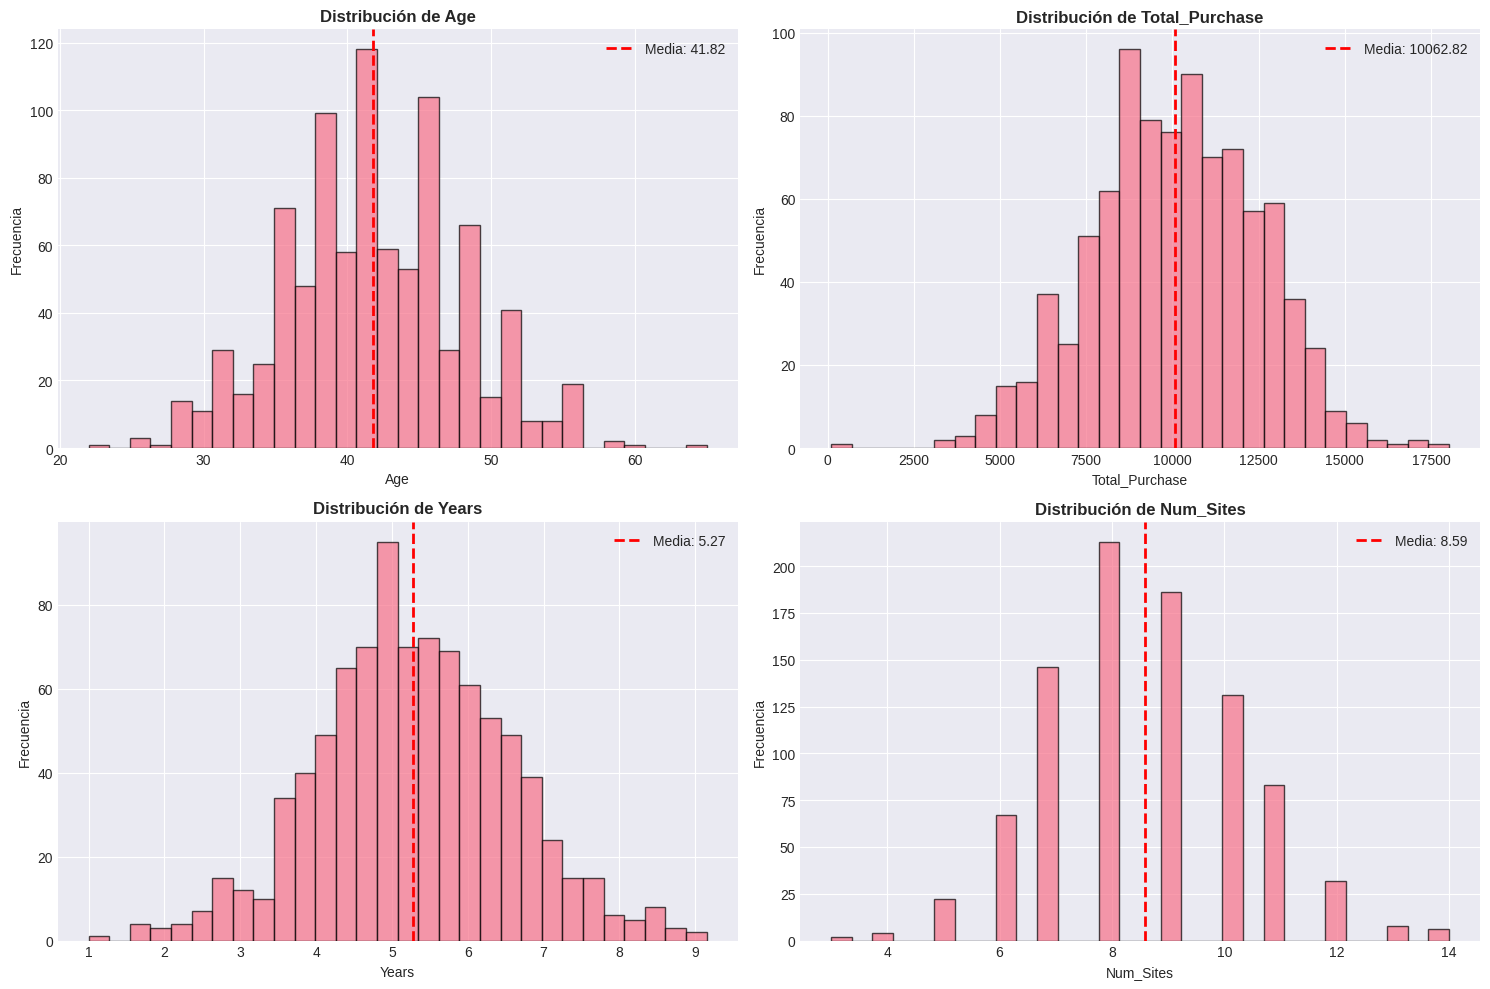

In [10]:
# 6. ANÁLISIS DE VARIABLES NUMÉRICAS
print("\n🔢 ANÁLISIS DE VARIABLES NUMÉRICAS")
print("-"*60)

# Seleccionar columnas numéricas
numeric_cols = ['Age', 'Total_Purchase', 'Years', 'Num_Sites']

# Distribución de variables numéricas
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    axes[idx].hist(df[col].dropna(), bins=30, edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'Distribución de {col}', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel(col, fontsize=10)
    axes[idx].set_ylabel('Frecuencia', fontsize=10)
    axes[idx].axvline(df[col].mean(), color='red', linestyle='--', 
                      linewidth=2, label=f'Media: {df[col].mean():.2f}')
    axes[idx].legend()

plt.tight_layout()
plt.show()



COMPARACIÓN DE VARIABLES POR CHURN
------------------------------------------------------------


/tmp/ipykernel_213/776687689.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, ax=axes[idx], palette='Set2')
/tmp/ipykernel_213/776687689.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(['No Abandonó', 'Abandonó'])
/tmp/ipykernel_213/776687689.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y=col, data=df, ax=axes[idx], palette='Set2')
/tmp/ipykernel_213/776687689.py:12: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[idx].set_xticklabels(['No Aban

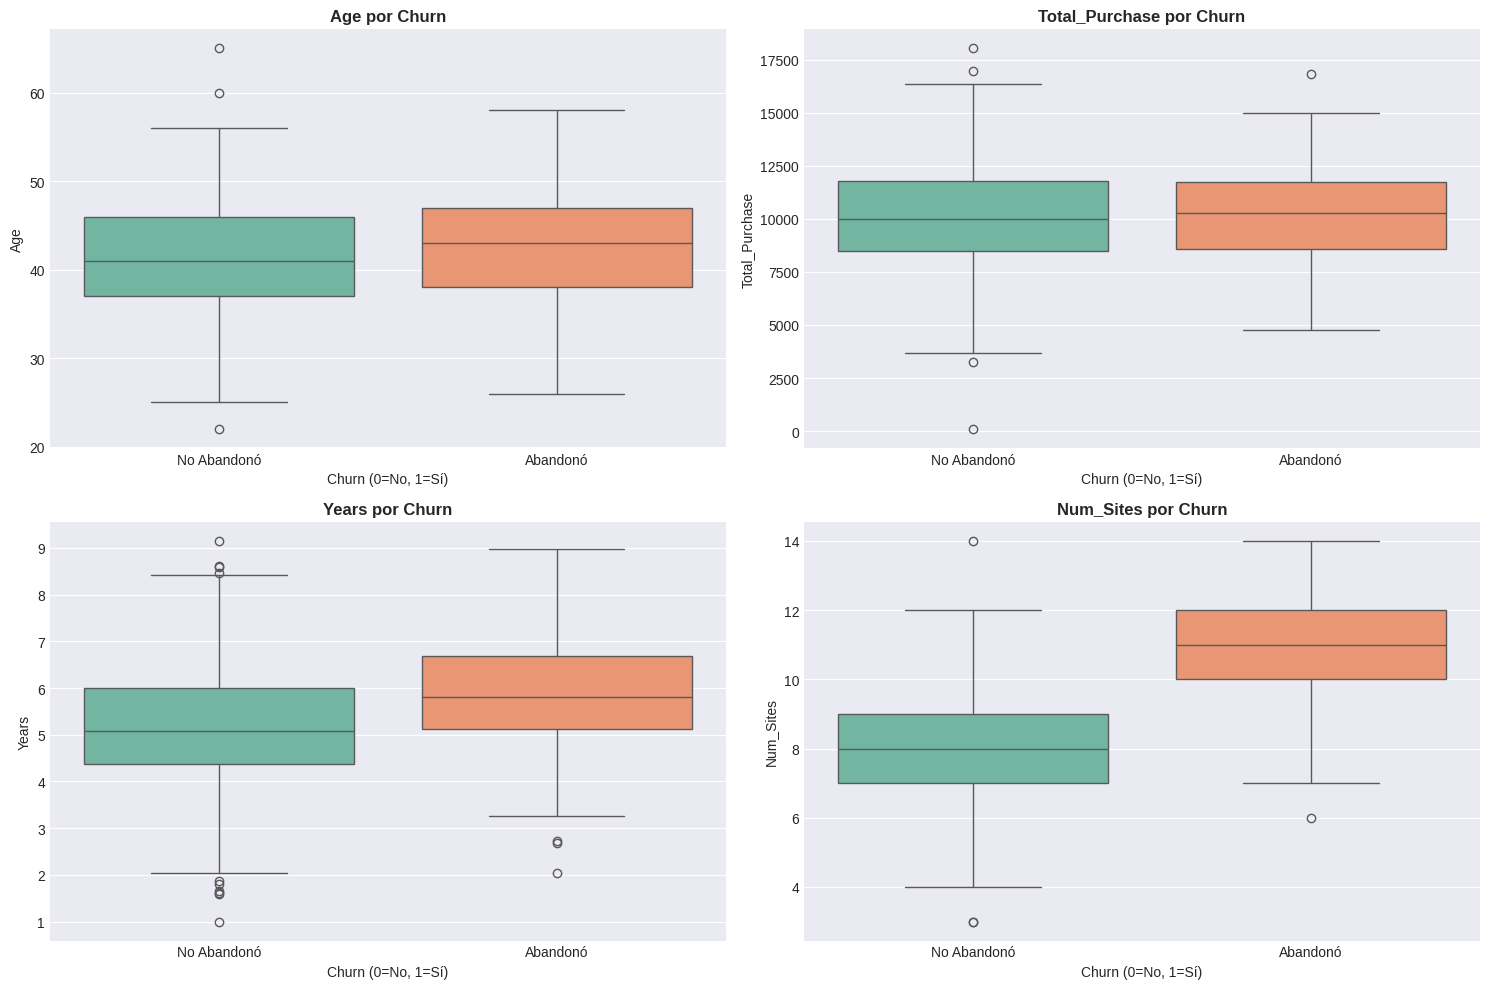


Estadísticas agrupadas por Churn:
             Age  Total_Purchase     Years  Num_Sites
Churn                                                
0      41.581333    10036.952853  5.151067   8.173333
1      42.993333    10192.179933  5.883600  10.660000


In [11]:
# 7. BOXPLOTS POR CHURN
print("\nCOMPARACIÓN DE VARIABLES POR CHURN")
print("-"*60)

fig, axes = plt.subplots(2, 2, figsize=(15, 10))
axes = axes.ravel()

for idx, col in enumerate(numeric_cols):
    sns.boxplot(x='Churn', y=col, data=df, ax=axes[idx], palette='Set2')
    axes[idx].set_title(f'{col} por Churn', fontsize=12, fontweight='bold')
    axes[idx].set_xlabel('Churn (0=No, 1=Sí)', fontsize=10)
    axes[idx].set_xticklabels(['No Abandonó', 'Abandonó'])

plt.tight_layout()
plt.show()

# Estadísticas por grupo de Churn
print("\nEstadísticas agrupadas por Churn:")
print(df.groupby('Churn')[numeric_cols].mean())




MATRIZ DE CORRELACIÓN
------------------------------------------------------------
                      Age  Total_Purchase     Years  Num_Sites  \
Age              1.000000       -0.037208  0.005625  -0.006070   
Total_Purchase  -0.037208        1.000000 -0.005623  -0.003390   
Years            0.005625       -0.005623  1.000000   0.051642   
Num_Sites       -0.006070       -0.003390  0.051642   1.000000   
Account_Manager -0.014749        0.015856  0.022930   0.033401   
Churn            0.085926        0.024031  0.214329   0.525398   

                 Account_Manager     Churn  
Age                    -0.014749  0.085926  
Total_Purchase          0.015856  0.024031  
Years                   0.022930  0.214329  
Num_Sites               0.033401  0.525398  
Account_Manager         1.000000  0.070611  
Churn                   0.070611  1.000000  


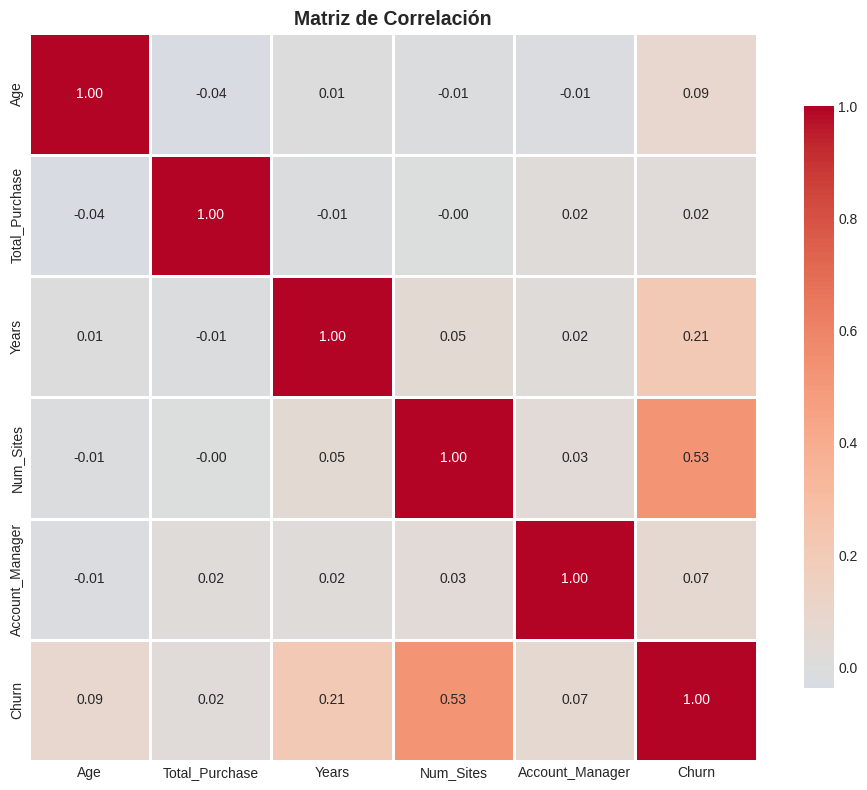

In [12]:
# 8. MATRIZ DE CORRELACIÓN
print("\nMATRIZ DE CORRELACIÓN")
print("-"*60)

# Crear matriz de correlación
correlation_cols = numeric_cols + ['Account_Manager', 'Churn']
corr_matrix = df[correlation_cols].corr()

print(corr_matrix)

# Heatmap de correlación
plt.figure(figsize=(10, 8))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, 
            fmt='.2f', linewidths=1, square=True, cbar_kws={"shrink": 0.8})
plt.title('Matriz de Correlación', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


ANÁLISIS DE ACCOUNT MANAGER
------------------------------------------------------------

Porcentaje de Churn por Account Manager:
Churn                    0          1
Account_Manager                      
0                85.867238  14.132762
1                80.600462  19.399538


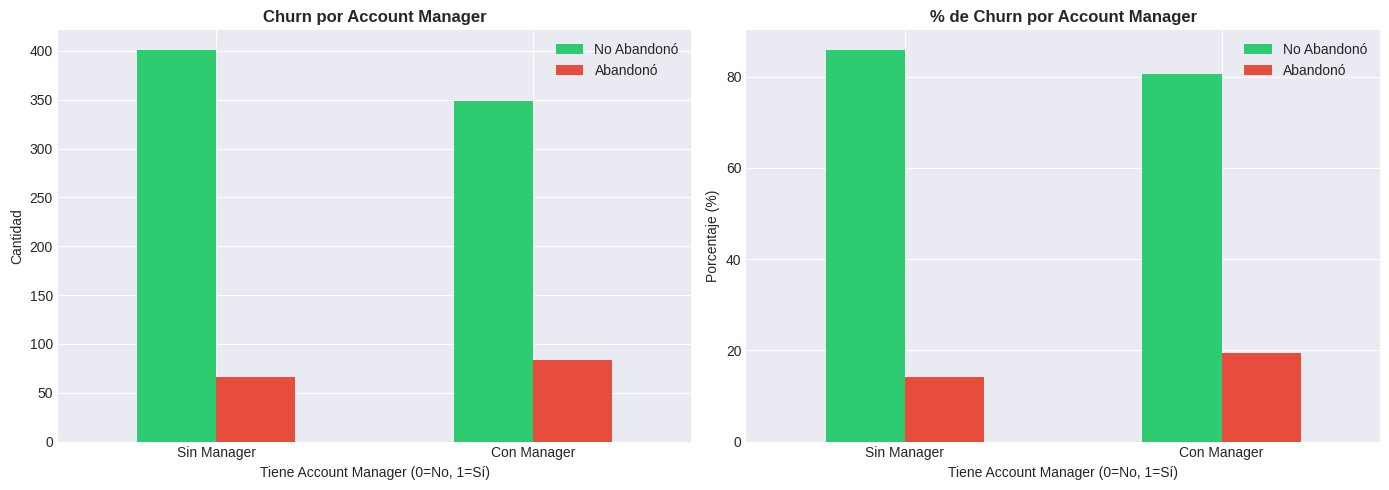

In [13]:
# 9. ANÁLISIS DE ACCOUNT MANAGER
print("\nANÁLISIS DE ACCOUNT MANAGER")
print("-"*60)

# Tabla cruzada
account_churn = pd.crosstab(df['Account_Manager'], df['Churn'], 
                             normalize='index') * 100
print("\nPorcentaje de Churn por Account Manager:")
print(account_churn)

# Gráfica
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Conteo
pd.crosstab(df['Account_Manager'], df['Churn']).plot(kind='bar', 
                                                       ax=axes[0], 
                                                       color=['#2ecc71', '#e74c3c'])
axes[0].set_title('Churn por Account Manager', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Tiene Account Manager (0=No, 1=Sí)', fontsize=10)
axes[0].set_ylabel('Cantidad', fontsize=10)
axes[0].set_xticklabels(['Sin Manager', 'Con Manager'], rotation=0)
axes[0].legend(['No Abandonó', 'Abandonó'])

# Porcentaje
account_churn.plot(kind='bar', ax=axes[1], color=['#2ecc71', '#e74c3c'])
axes[1].set_title('% de Churn por Account Manager', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Tiene Account Manager (0=No, 1=Sí)', fontsize=10)
axes[1].set_ylabel('Porcentaje (%)', fontsize=10)
axes[1].set_xticklabels(['Sin Manager', 'Con Manager'], rotation=0)
axes[1].legend(['No Abandonó', 'Abandonó'])

plt.tight_layout()
plt.show()



 ANÁLISIS DE RELACIONES ENTRE VARIABLES
------------------------------------------------------------


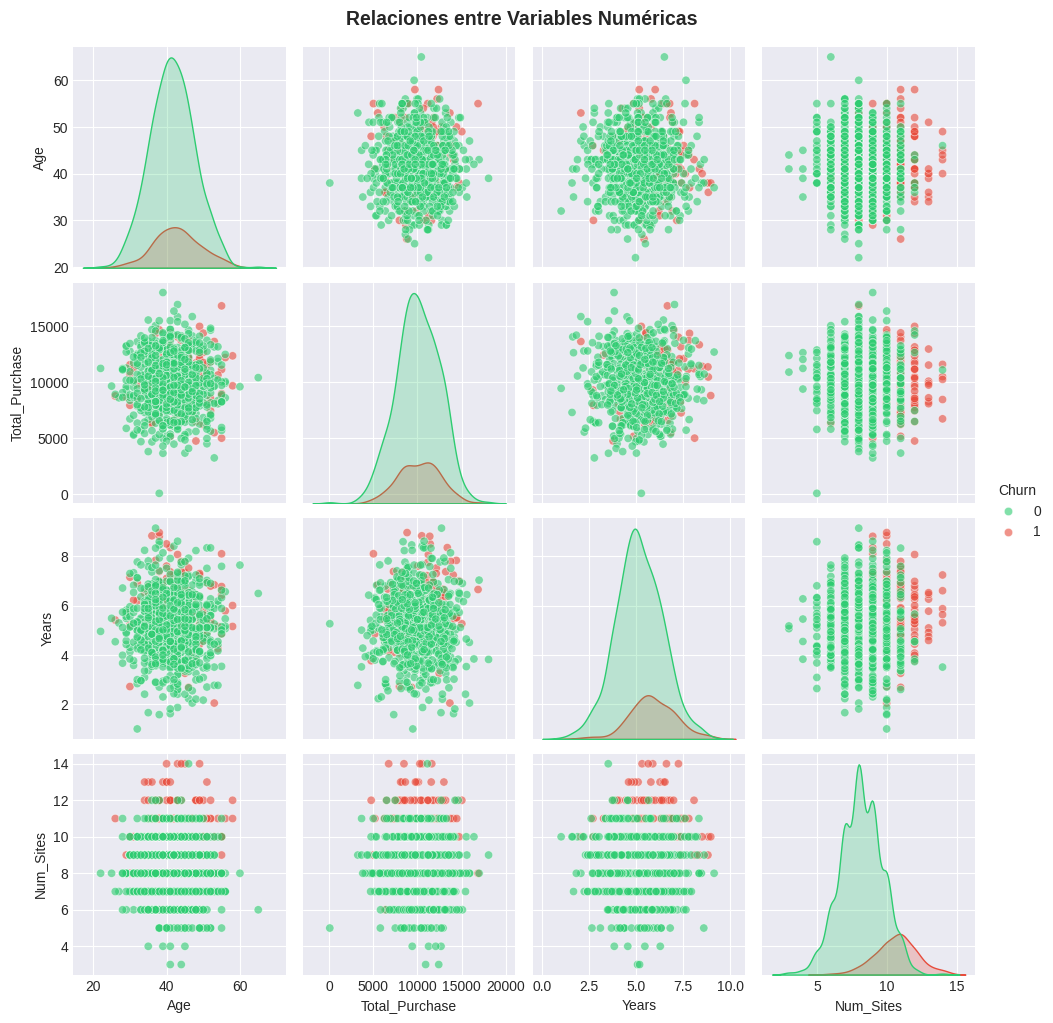

In [14]:
# 10. PAIRPLOT (RELACIONES ENTRE VARIABLES)
print("\n ANÁLISIS DE RELACIONES ENTRE VARIABLES")
print("-"*60)

# Pairplot
sns.pairplot(df[numeric_cols + ['Churn']], hue='Churn', 
             palette={0: '#2ecc71', 1: '#e74c3c'}, 
             plot_kws={'alpha': 0.6}, height=2.5)
plt.suptitle('Relaciones entre Variables Numéricas', y=1.02, 
             fontsize=14, fontweight='bold')
plt.show()

In [15]:
# 11. RESUMEN EJECUTIVO
print("\n" + "="*60)
print("RESUMEN EJECUTIVO")
print("="*60)
print(f"\n✅ Total de clientes: {len(df)}")
print(f"✅ Clientes que abandonaron: {churn_counts[1]} ({churn_pct[1]:.2f}%)")
print(f"✅ Clientes que NO abandonaron: {churn_counts[0]} ({churn_pct[0]:.2f}%)")
print(f"\n✅ Variables numéricas disponibles: {len(numeric_cols)}")
print(f"✅ Variables categó ricas: Names, Location, Company, Onboard_date")
print(f"\n✅ Clientes con Account Manager: {df['Account_Manager'].sum()}")
print(f"✅ Clientes sin Account Manager: {len(df) - df['Account_Manager'].sum()}")

print("\n" + "="*60)
print("¡ANÁLISIS EXPLORATORIO COMPLETADO!")
print("="*60)


RESUMEN EJECUTIVO

✅ Total de clientes: 900
✅ Clientes que abandonaron: 150 (16.67%)
✅ Clientes que NO abandonaron: 750 (83.33%)

✅ Variables numéricas disponibles: 4
✅ Variables categó ricas: Names, Location, Company, Onboard_date

✅ Clientes con Account Manager: 433
✅ Clientes sin Account Manager: 467

¡ANÁLISIS EXPLORATORIO COMPLETADO!
